# Interpreting the Embedding Dimensions

Diagnostics to understand what each embedding dimension at z=0 captures geometrically: correlations with summary statistics of the sorted-neighbor vector, and direct visual inspection of the sorted vectors for galaxies at the extremes of each dimension.

**Tentative interpretations** (updated as evidence accumulates):
- **Dim 1**: total neighbor count (overall density). Strongest correlate: `r(n_neighbors) = -0.899`.
- **Dim 2**: steepness / shape of the rank–distance curve. Bimodal classifier separating dense cluster cores from isolated voids; at fixed Dim 1, picks out how rapidly distances spread with rank.
- **Dim 3**: nearest-neighbor distance / presence of close companions. At fixed density, separates galaxies that have a close neighbor from those that don't.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

## Load z=0 embedding

The interpretation only uses the **native** z=0 embedding and its sorted-neighbor matrix (no Nyström projection needed).

In [2]:
data = np.load('snapshot99_embedding.npz')
X = {99: data['embedding']}                # (N, 10) MDS coordinates
sn = {99: data['sorted_neighbors']}        # (N, N) sorted distances per galaxy
print(f'Embedding: {X[99].shape}')
print(f'Sorted neighbors: {sn[99].shape}')

Embedding: (10000, 10)
Sorted neighbors: (10000, 10000)


## 1. Correlations between embedding dimensions and summary statistics

In [24]:
from scipy.stats import skew, kurtosis

def per_galaxy_stat(sn_matrix, stat_fn):
    """Apply stat_fn to the nonzero entries of each row. Returns 0 if too few entries."""
    out = np.zeros(sn_matrix.shape[0])
    for i, v in enumerate(sn_matrix):
        nz = v[v > 0]
        if len(nz) >= 2:
            out[i] = stat_fn(nz)
    return out

# Basic stats
n_neighbors = np.sum(sn[99] > 0, axis=1)
mean_dist   = per_galaxy_stat(sn[99], np.mean)
std_dist    = per_galaxy_stat(sn[99], np.std)

# Shape stats
skew_dist   = per_galaxy_stat(sn[99], skew)
kurt_dist   = per_galaxy_stat(sn[99], kurtosis)  # Fisher (excess) kurtosis by default

# Quantiles of the nonzero distance distribution
q05_dist = per_galaxy_stat(sn[99], lambda v: np.percentile(v, 5))
q25_dist = per_galaxy_stat(sn[99], lambda v: np.percentile(v, 25))
q50_dist = per_galaxy_stat(sn[99], lambda v: np.percentile(v, 50))
q75_dist = per_galaxy_stat(sn[99], lambda v: np.percentile(v, 75))
q95_dist = per_galaxy_stat(sn[99], lambda v: np.percentile(v, 95))

stats = {
    'n_neighbors': n_neighbors,
    'mean_dist':   mean_dist,
    'std_dist':    std_dist,
    'skew_dist':   skew_dist,
    'kurt_dist':   kurt_dist,
    'q05_dist':    q05_dist,
    'q25_dist':    q25_dist,
    'q50_dist':    q50_dist,
    'q75_dist':    q75_dist,
    'q95_dist':    q95_dist,
}

# Build a correlation table (rows = Dims, cols = stats)
print(f'{"Dim":>5}', end=' ')
for name in stats:
    print(f'{name:>13}', end=' ')
print()
for d in range(3):
    print(f'{d+1:>5}', end=' ')
    for name, vals in stats.items():
        r = np.corrcoef(X[99][:, d], vals)[0, 1]
        if np.abs(r) >= 0.1:
            print(f'{r:>+12.3f}*', end=' ')
        else:
            print(f'{r:>+12.3f} ', end=' ')
    print()

  Dim   n_neighbors     mean_dist      std_dist     skew_dist     kurt_dist      q05_dist      q25_dist      q50_dist      q75_dist      q95_dist 
    1       -0.899*       +0.071        -0.083        -0.024        -0.128*       +0.161*       +0.105*       +0.092        +0.018        -0.163* 
    2       -0.233*       +0.096        +0.165*       -0.132*       +0.074        -0.108*       +0.004        +0.111*       +0.201*       +0.228* 
    3       -0.213*       -0.101*       -0.062        +0.105*       -0.125*       +0.027        -0.069        -0.075        -0.140*       -0.210* 


## 2. Sorted-neighbor vectors at the Dim 2 peaks

Negative-peak Dim 2 values: min=-2.63, max=-2.60
Positive-peak Dim 2 values: min=1.80, max=1.84
Mid-Dim 2 values:           min=-0.01, max=0.00


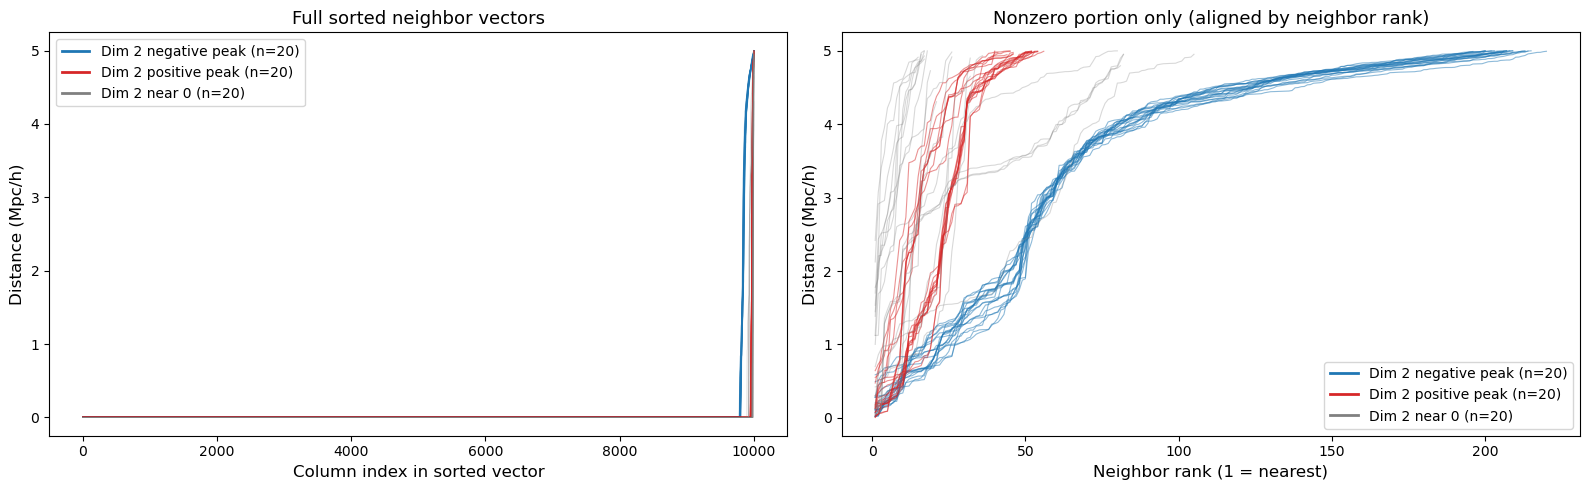

In [4]:
# Compare sorted-neighbor vectors for galaxies at the two Dim 2 peaks
n_per_peak = 20
neg_peak_idx = np.argsort(X[99][:, 1])[:n_per_peak]              # lowest Dim 2 galaxies
pos_peak_idx = np.argsort(X[99][:, 1])[-n_per_peak:]             # highest Dim 2 galaxies
median_idx   = np.argsort(np.abs(X[99][:, 1]))[:n_per_peak]      # near 0 for contrast

print(f'Negative-peak Dim 2 values: '
      f'min={X[99][neg_peak_idx, 1].min():.2f}, max={X[99][neg_peak_idx, 1].max():.2f}')
print(f'Positive-peak Dim 2 values: '
      f'min={X[99][pos_peak_idx, 1].min():.2f}, max={X[99][pos_peak_idx, 1].max():.2f}')
print(f'Mid-Dim 2 values:           '
      f'min={X[99][median_idx, 1].min():.2f}, max={X[99][median_idx, 1].max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for i in neg_peak_idx:
    ax.plot(sn[99][i], color='tab:blue', alpha=0.5, lw=0.8)
for i in pos_peak_idx:
    ax.plot(sn[99][i], color='tab:red', alpha=0.5, lw=0.8)
for i in median_idx:
    ax.plot(sn[99][i], color='gray', alpha=0.3, lw=0.6)
ax.set_xlabel('Column index in sorted vector', fontsize=12)
ax.set_ylabel('Distance (Mpc/h)', fontsize=12)
ax.set_title('Full sorted neighbor vectors', fontsize=13)

ax = axes[1]
def plot_nonzero(idx_list, color, alpha=0.5):
    for i in idx_list:
        v = sn[99][i]
        nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color=color, alpha=alpha, lw=0.8)

plot_nonzero(neg_peak_idx, 'tab:blue')
plot_nonzero(pos_peak_idx, 'tab:red')
plot_nonzero(median_idx, 'gray', alpha=0.3)
ax.set_xlabel('Neighbor rank (1 = nearest)', fontsize=12)
ax.set_ylabel('Distance (Mpc/h)', fontsize=12)
ax.set_title('Nonzero portion only (aligned by neighbor rank)', fontsize=13)

legend = [
    Line2D([0], [0], color='tab:blue', lw=2, label=f'Dim 2 negative peak (n={n_per_peak})'),
    Line2D([0], [0], color='tab:red',  lw=2, label=f'Dim 2 positive peak (n={n_per_peak})'),
    Line2D([0], [0], color='gray',     lw=2, label=f'Dim 2 near 0 (n={n_per_peak})'),
]
axes[0].legend(handles=legend, fontsize=10)
axes[1].legend(handles=legend, fontsize=10)
plt.tight_layout()
plt.show()

## 3. Sorted-neighbor vectors at the Dim 3 peaks

Negative Dim 3 values: min=-2.00, max=-1.98
Positive Dim 3 values: min=1.34, max=1.40
Mid Dim 3 values:      min=-0.00, max=0.00


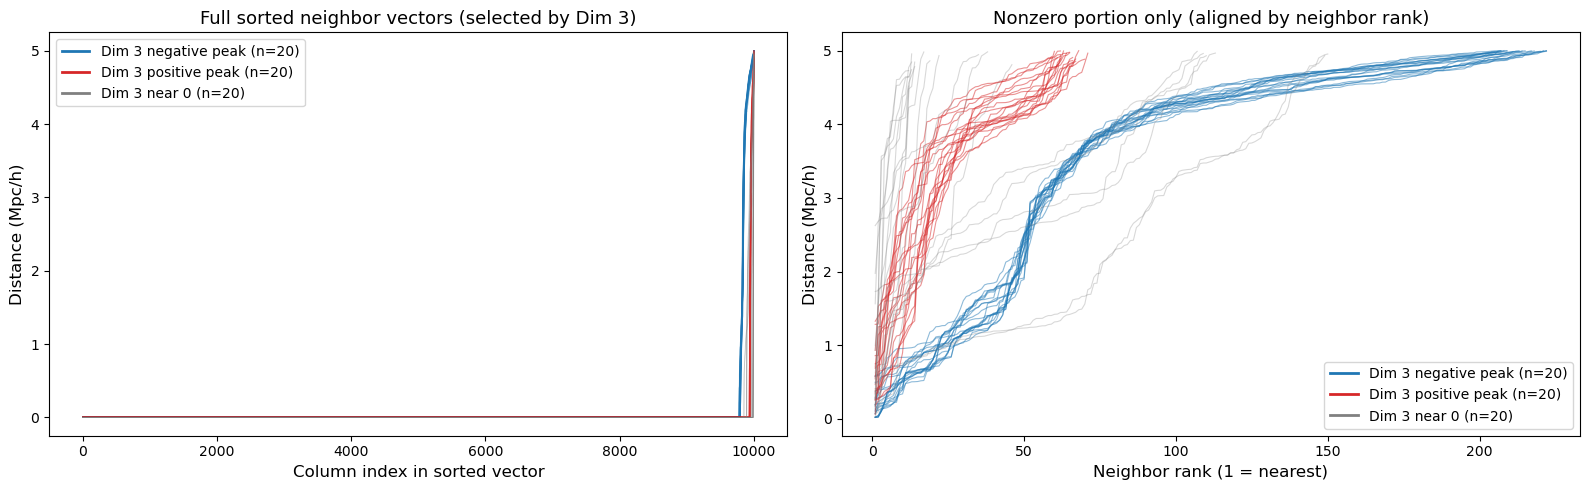

In [5]:
n_per_peak = 20
neg_peak_idx = np.argsort(X[99][:, 2])[:n_per_peak]
pos_peak_idx = np.argsort(X[99][:, 2])[-n_per_peak:]
median_idx   = np.argsort(np.abs(X[99][:, 2]))[:n_per_peak]

print(f'Negative Dim 3 values: min={X[99][neg_peak_idx, 2].min():.2f}, max={X[99][neg_peak_idx, 2].max():.2f}')
print(f'Positive Dim 3 values: min={X[99][pos_peak_idx, 2].min():.2f}, max={X[99][pos_peak_idx, 2].max():.2f}')
print(f'Mid Dim 3 values:      min={X[99][median_idx, 2].min():.2f}, max={X[99][median_idx, 2].max():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
for i in neg_peak_idx:
    ax.plot(sn[99][i], color='tab:blue', alpha=0.5, lw=0.8)
for i in pos_peak_idx:
    ax.plot(sn[99][i], color='tab:red', alpha=0.5, lw=0.8)
for i in median_idx:
    ax.plot(sn[99][i], color='gray', alpha=0.3, lw=0.6)
ax.set_xlabel('Column index in sorted vector', fontsize=12)
ax.set_ylabel('Distance (Mpc/h)', fontsize=12)
ax.set_title('Full sorted neighbor vectors (selected by Dim 3)', fontsize=13)

ax = axes[1]
def plot_nonzero(idx_list, color, alpha=0.5):
    for i in idx_list:
        v = sn[99][i]
        nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color=color, alpha=alpha, lw=0.8)

plot_nonzero(neg_peak_idx, 'tab:blue')
plot_nonzero(pos_peak_idx, 'tab:red')
plot_nonzero(median_idx, 'gray', alpha=0.3)
ax.set_xlabel('Neighbor rank (1 = nearest)', fontsize=12)
ax.set_ylabel('Distance (Mpc/h)', fontsize=12)
ax.set_title('Nonzero portion only (aligned by neighbor rank)', fontsize=13)

legend = [
    Line2D([0], [0], color='tab:blue', lw=2, label=f'Dim 3 negative peak (n={n_per_peak})'),
    Line2D([0], [0], color='tab:red',  lw=2, label=f'Dim 3 positive peak (n={n_per_peak})'),
    Line2D([0], [0], color='gray',     lw=2, label=f'Dim 3 near 0 (n={n_per_peak})'),
]
axes[0].legend(handles=legend, fontsize=10)
axes[1].legend(handles=legend, fontsize=10)
plt.tight_layout()
plt.show()

## 4. Dim 3 controlling for Dim 2

Pick galaxies near zero in Dim 2 (the uncommitted middle), then select extreme Dim 3 from that subset. Isolates Dim 3's unique signal.

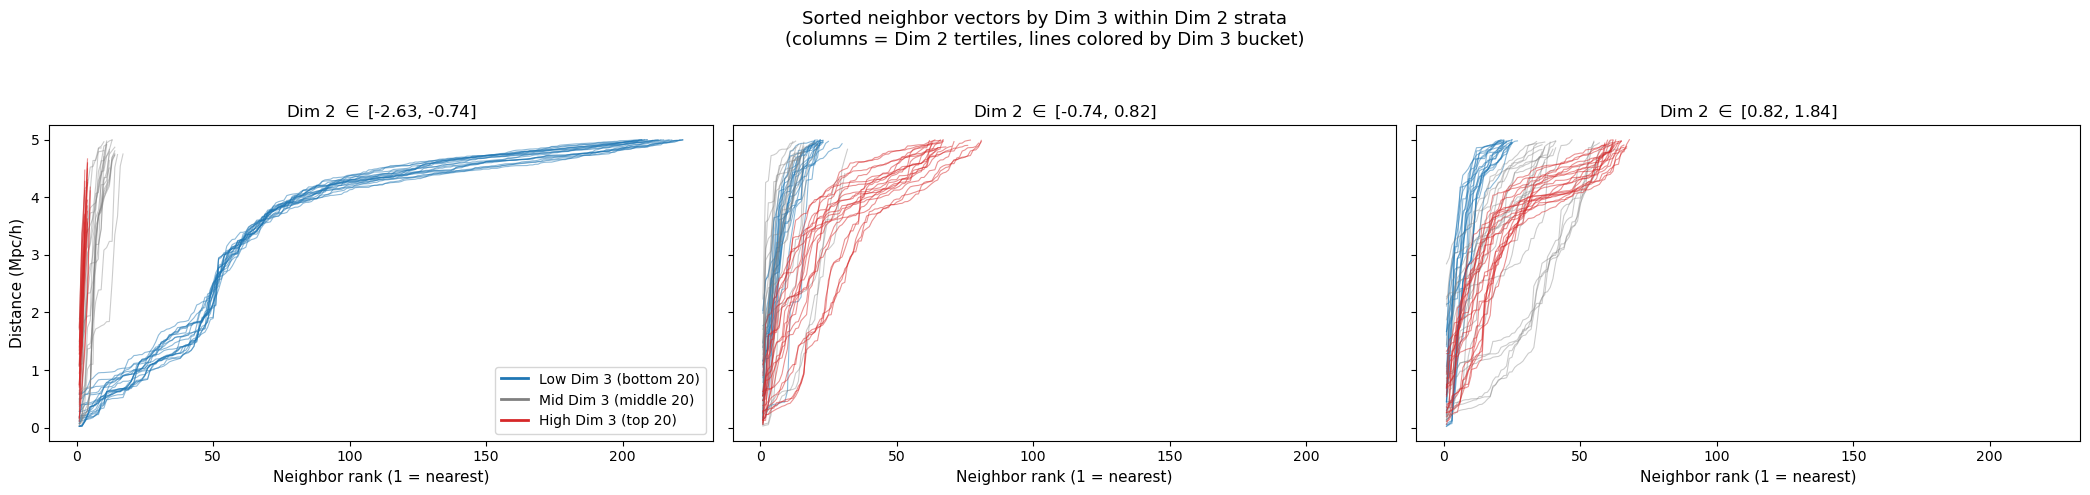

In [25]:
# Subplots: columns = ranges of Dim 2. Within each, plot sorted distance vectors
# for galaxies in low/middle/high Dim 3 buckets.

n_per_group = 20
n_strata_d2 = 3

d2_vals = X[99][:, 1]
# Tertiles of Dim 2 (or use hand-picked edges like np.array([-2, -0.5, 0.5, 2]))
d2_edges = np.percentile(d2_vals, np.linspace(0, 100, n_strata_d2 + 1))
d2_idx_stratum = np.clip(np.digitize(d2_vals, d2_edges) - 1, 0, n_strata_d2 - 1)
d2_titles = [f'Dim 2 $\\in$ [{d2_edges[i]:.2f}, {d2_edges[i+1]:.2f}]'
             for i in range(n_strata_d2)]

fig, axes = plt.subplots(1, n_strata_d2, figsize=(7 * n_strata_d2, 5), sharex=True, sharey=True)

for col in range(n_strata_d2):
    ax = axes[col]
    pool = np.where(d2_idx_stratum == col)[0]
    if len(pool) < 3 * n_per_group:
        ax.text(0.5, 0.5, f'Only {len(pool)} galaxies in stratum',
                transform=ax.transAxes, ha='center', va='center')
        ax.set_title(d2_titles[col], fontsize=12)
        continue

    # Within this Dim 2 stratum, sort by Dim 3 and grab bottom/middle/top 20
    sorted_pool = pool[np.argsort(X[99][pool, 2])]
    bottom_idx = sorted_pool[:n_per_group]                                # low Dim 3
    top_idx    = sorted_pool[-n_per_group:]                                # high Dim 3
    median_pos = len(sorted_pool) // 2
    mid_idx    = sorted_pool[median_pos - n_per_group // 2 : median_pos + n_per_group // 2]

    for i in bottom_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='tab:blue', alpha=0.5, lw=0.8)
    for i in mid_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='gray', alpha=0.4, lw=0.8)
    for i in top_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='tab:red', alpha=0.5, lw=0.8)

    ax.set_title(d2_titles[col], fontsize=12)
    ax.set_xlabel('Neighbor rank (1 = nearest)', fontsize=11)
    if col == 0:
        ax.set_ylabel('Distance (Mpc/h)', fontsize=11)

legend = [
    Line2D([0], [0], color='tab:blue', lw=2, label=f'Low Dim 3 (bottom {n_per_group})'),
    Line2D([0], [0], color='gray',     lw=2, label=f'Mid Dim 3 (middle {n_per_group})'),
    Line2D([0], [0], color='tab:red',  lw=2, label=f'High Dim 3 (top {n_per_group})'),
]
axes[0].legend(handles=legend, fontsize=10, loc='lower right')

fig.suptitle('Sorted neighbor vectors by Dim 3 within Dim 2 strata\n'
             '(columns = Dim 2 tertiles, lines colored by Dim 3 bucket)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## 5. Three-dimension overview: bottom/middle/top by each Dim

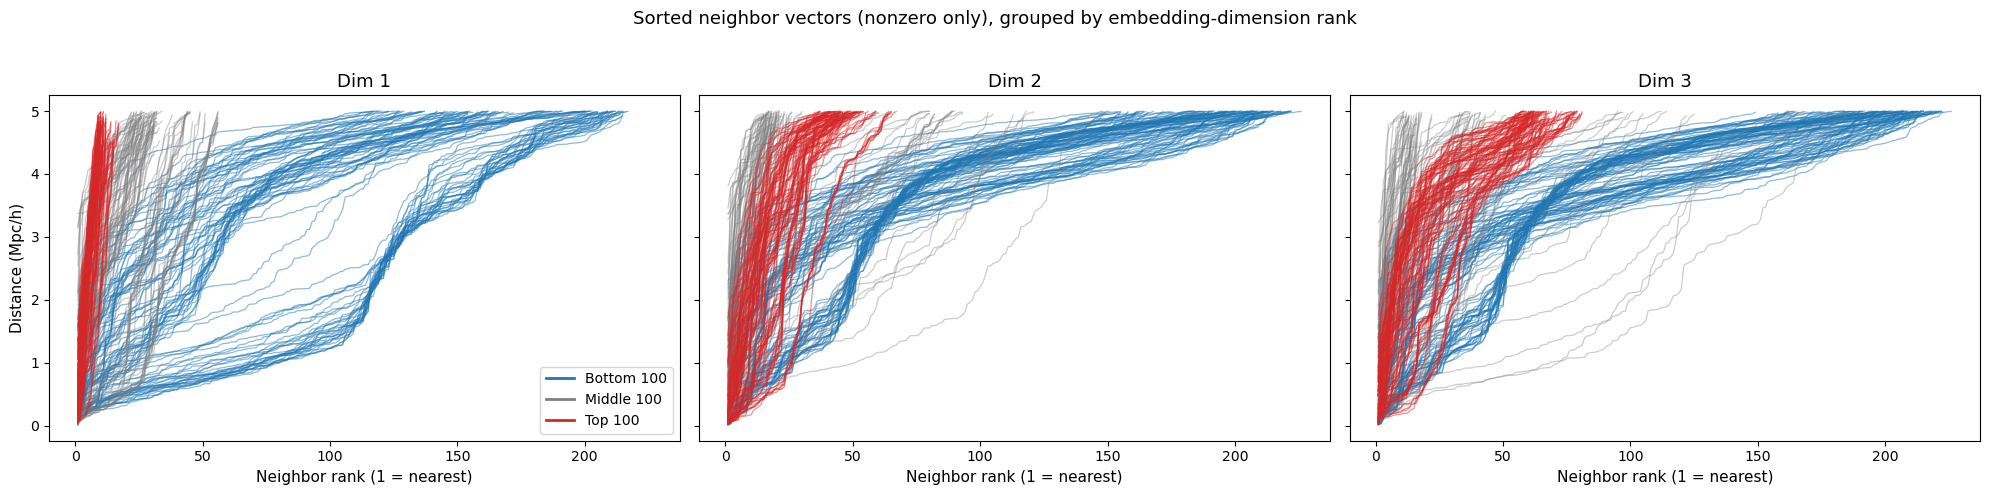

In [7]:
n_per_group = 100
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

for col, dim in enumerate([0, 1, 2]):
    vals = X[99][:, dim]
    order = np.argsort(vals)
    bottom_idx = order[:n_per_group]
    top_idx    = order[-n_per_group:]
    median_pos = len(order) // 2
    mid_idx    = order[median_pos - n_per_group // 2 : median_pos + n_per_group // 2]

    ax = axes[col]
    for i in bottom_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='tab:blue', alpha=0.5, lw=0.9)
    for i in mid_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='gray', alpha=0.4, lw=0.9)
    for i in top_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='tab:red', alpha=0.5, lw=0.9)

    ax.set_title(f'Dim {dim+1}', fontsize=13)
    ax.set_xlabel('Neighbor rank (1 = nearest)', fontsize=11)
    if col == 0:
        ax.set_ylabel('Distance (Mpc/h)', fontsize=11)

legend = [
    Line2D([0], [0], color='tab:blue', lw=2, label=f'Bottom {n_per_group}'),
    Line2D([0], [0], color='gray',     lw=2, label=f'Middle {n_per_group}'),
    Line2D([0], [0], color='tab:red',  lw=2, label=f'Top {n_per_group}'),
]
axes[0].legend(handles=legend, fontsize=10, loc='lower right')
fig.suptitle('Sorted neighbor vectors (nonzero only), grouped by embedding-dimension rank', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

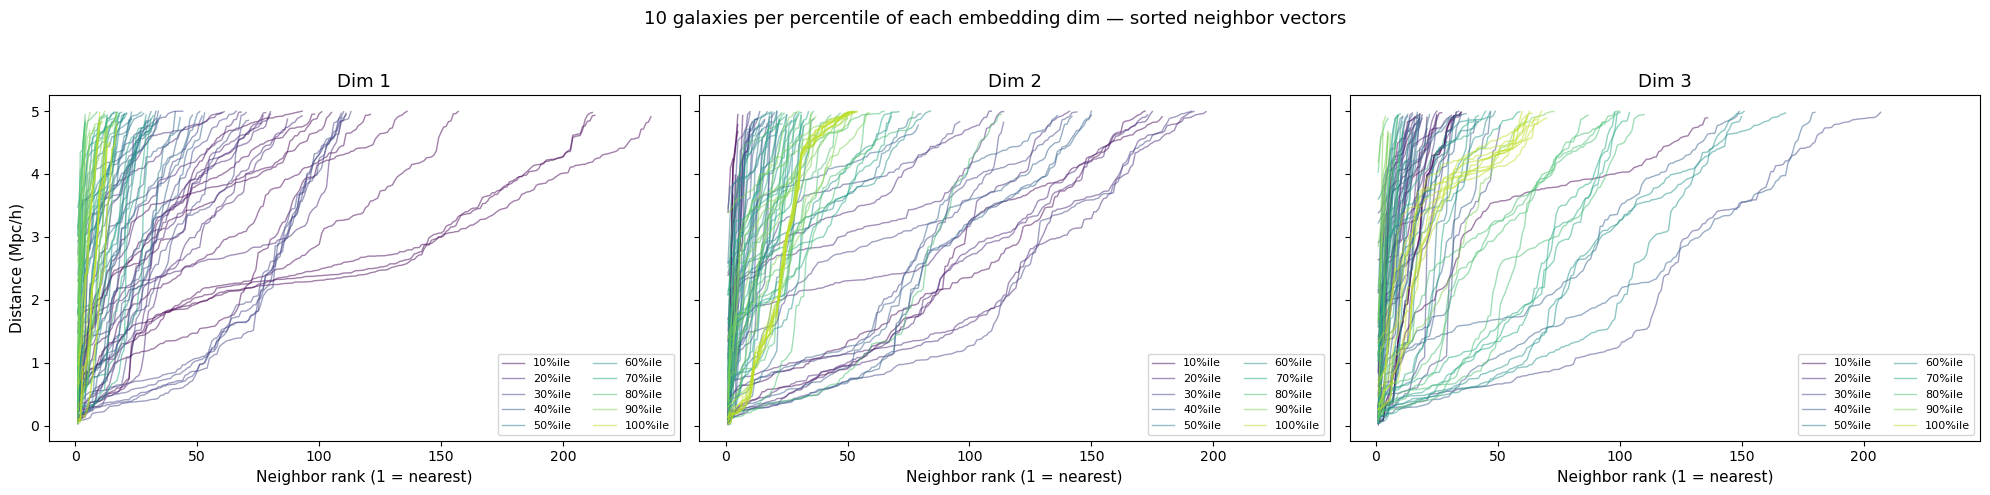

In [14]:
percentiles = np.arange(10, 101, 10)  # 10th, 20th, ..., 100th percentile
n_per_percentile = 10
colors = plt.cm.viridis(np.linspace(0, 0.9, len(percentiles)))

fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)

for col, dim in enumerate([0, 1, 2]):
    vals = X[99][:, dim]
    p_targets = np.percentile(vals, percentiles)

    ax = axes[col]
    for p, p_target, color in zip(percentiles, p_targets, colors):
        # 10 galaxies whose Dim values are closest to this percentile target
        nearest = np.argsort(np.abs(vals - p_target))[:n_per_percentile]
        for k, i in enumerate(nearest):
            v = sn[99][i]
            nz = v[v > 0]
            ax.plot(np.arange(1, len(nz) + 1), nz, color=color, lw=1.0, alpha=0.5,
                    label=f'{p}%ile' if k == 0 else None)

    ax.set_title(f'Dim {dim+1}', fontsize=13)
    ax.set_xlabel('Neighbor rank (1 = nearest)', fontsize=11)
    if col == 0:
        ax.set_ylabel('Distance (Mpc/h)', fontsize=11)
    ax.legend(fontsize=8, loc='lower right', ncol=2)

fig.suptitle(f'{n_per_percentile} galaxies per percentile of each embedding dim — sorted neighbor vectors',
             fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()



## 6. Dim 2 and Dim 3 within Dim 1 strata

Control for overall density (Dim 1) by tertile and look at what Dim 2 / Dim 3 distinguish *within* each density slice. The mid-density column is where Dim 2 and Dim 3 most clearly diverge: Dim 3 cleanly separates galaxies with vs without a close neighbor.

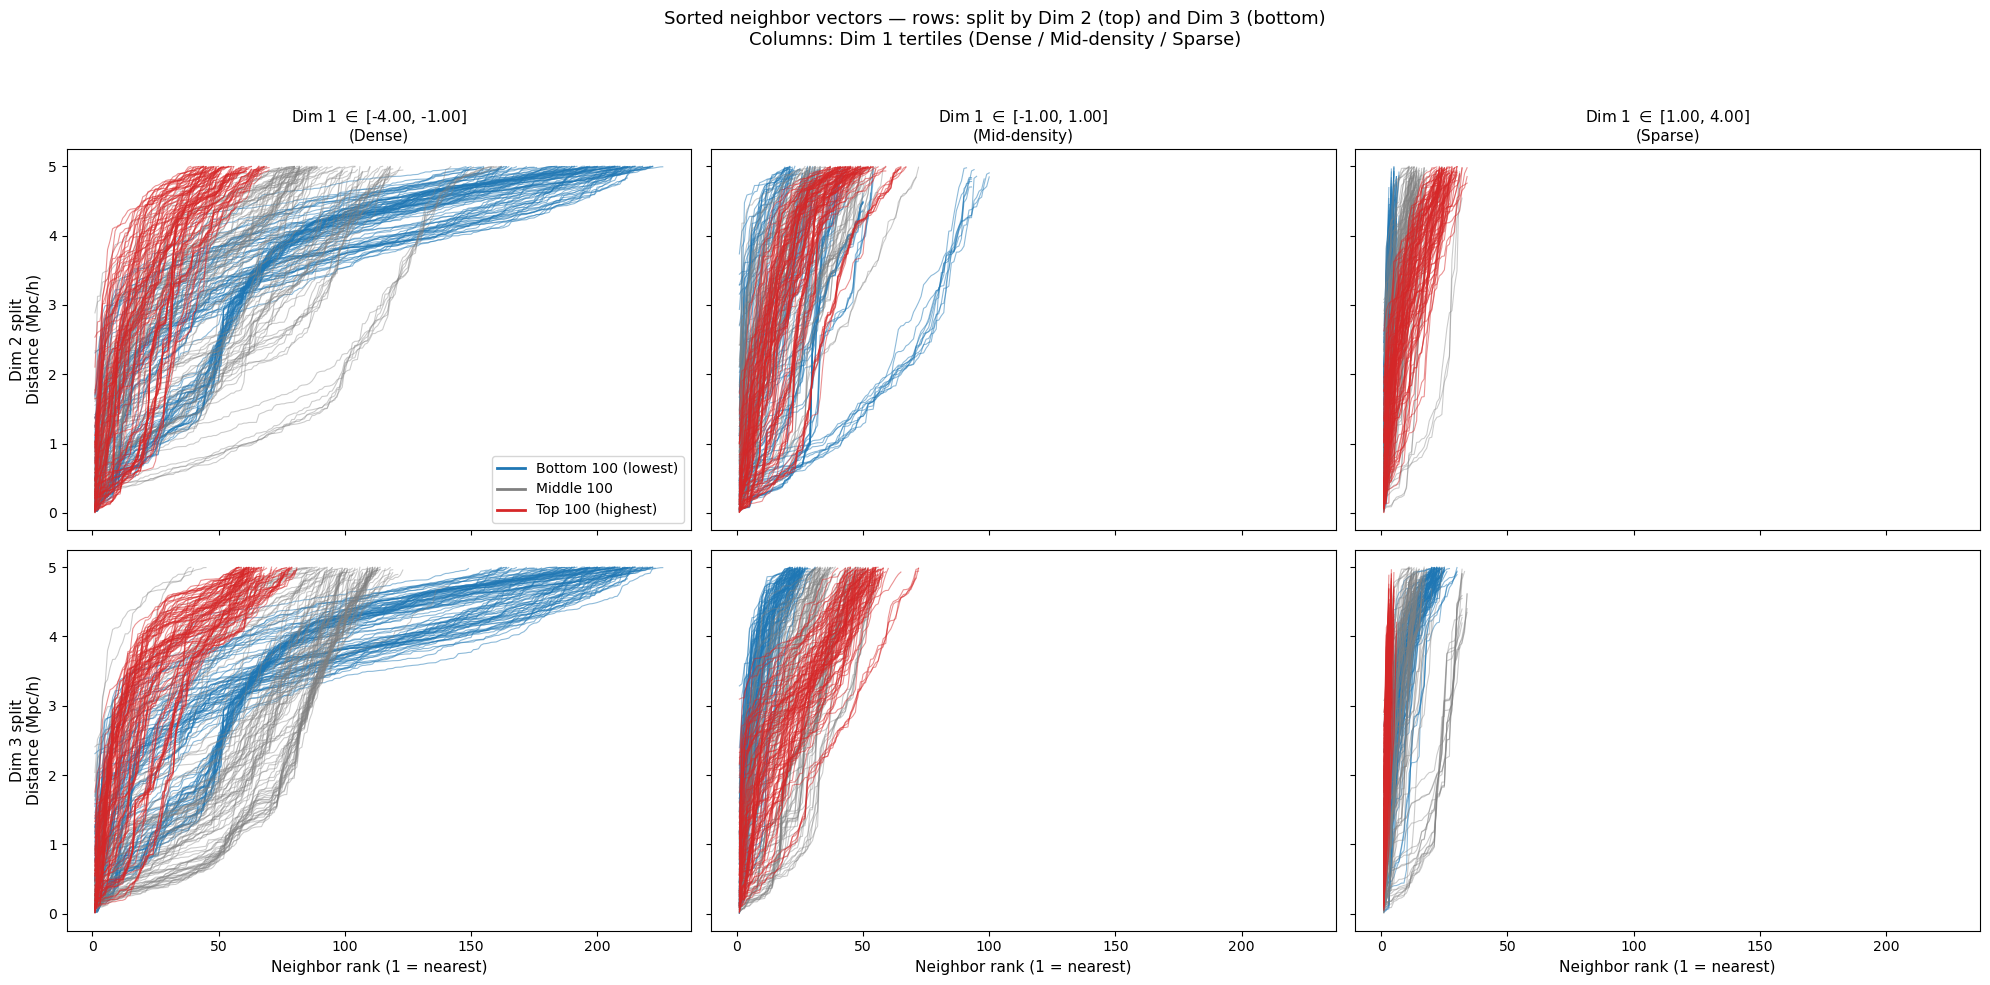

In [15]:
n_per_group = 100
n_strata_d1 = 3

d1_vals = X[99][:, 0]
d1_edges = np.array([-4, -1, 1, 4])  # hand-picked thresholds; switch to np.percentile for tertiles
d1_idx_stratum = np.clip(np.digitize(d1_vals, d1_edges) - 1, 0, n_strata_d1 - 1)
d1_titles = [f'Dim 1 $\\in$ [{d1_edges[i]:.2f}, {d1_edges[i+1]:.2f}]\n'
             f'({"Dense" if i == 0 else "Mid-density" if i == 1 else "Sparse"})'
             for i in range(n_strata_d1)]

fig, axes = plt.subplots(2, n_strata_d1, figsize=(20, 10), sharex=True, sharey=True)

def plot_grouped(ax, dim_to_rank, mask):
    pool = np.where(mask)[0]
    if len(pool) < 3 * n_per_group:
        ax.text(0.5, 0.5, f'Only {len(pool)} galaxies in stratum',
                transform=ax.transAxes, ha='center', va='center')
        return
    sorted_pool = pool[np.argsort(X[99][pool, dim_to_rank])]
    bottom_idx = sorted_pool[:n_per_group]
    top_idx    = sorted_pool[-n_per_group:]
    median_pos = len(sorted_pool) // 2
    mid_idx    = sorted_pool[median_pos - n_per_group // 2 : median_pos + n_per_group // 2]
    for i in bottom_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='tab:blue', alpha=0.5, lw=0.8)
    for i in mid_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='gray', alpha=0.4, lw=0.8)
    for i in top_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='tab:red', alpha=0.5, lw=0.8)

for col in range(n_strata_d1):
    mask = (d1_idx_stratum == col)
    plot_grouped(axes[0, col], 1, mask)
    axes[0, col].set_title(d1_titles[col], fontsize=11)
    if col == 0:
        axes[0, col].set_ylabel('Dim 2 split\nDistance (Mpc/h)', fontsize=11)
    plot_grouped(axes[1, col], 2, mask)
    if col == 0:
        axes[1, col].set_ylabel('Dim 3 split\nDistance (Mpc/h)', fontsize=11)
    axes[1, col].set_xlabel('Neighbor rank (1 = nearest)', fontsize=11)

legend = [
    Line2D([0], [0], color='tab:blue', lw=2, label=f'Bottom {n_per_group} (lowest)'),
    Line2D([0], [0], color='gray',     lw=2, label=f'Middle {n_per_group}'),
    Line2D([0], [0], color='tab:red',  lw=2, label=f'Top {n_per_group} (highest)'),
]
axes[0, 0].legend(handles=legend, fontsize=10, loc='lower right')
fig.suptitle('Sorted neighbor vectors — rows: split by Dim 2 (top) and Dim 3 (bottom)\n'
             'Columns: Dim 1 tertiles (Dense / Mid-density / Sparse)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

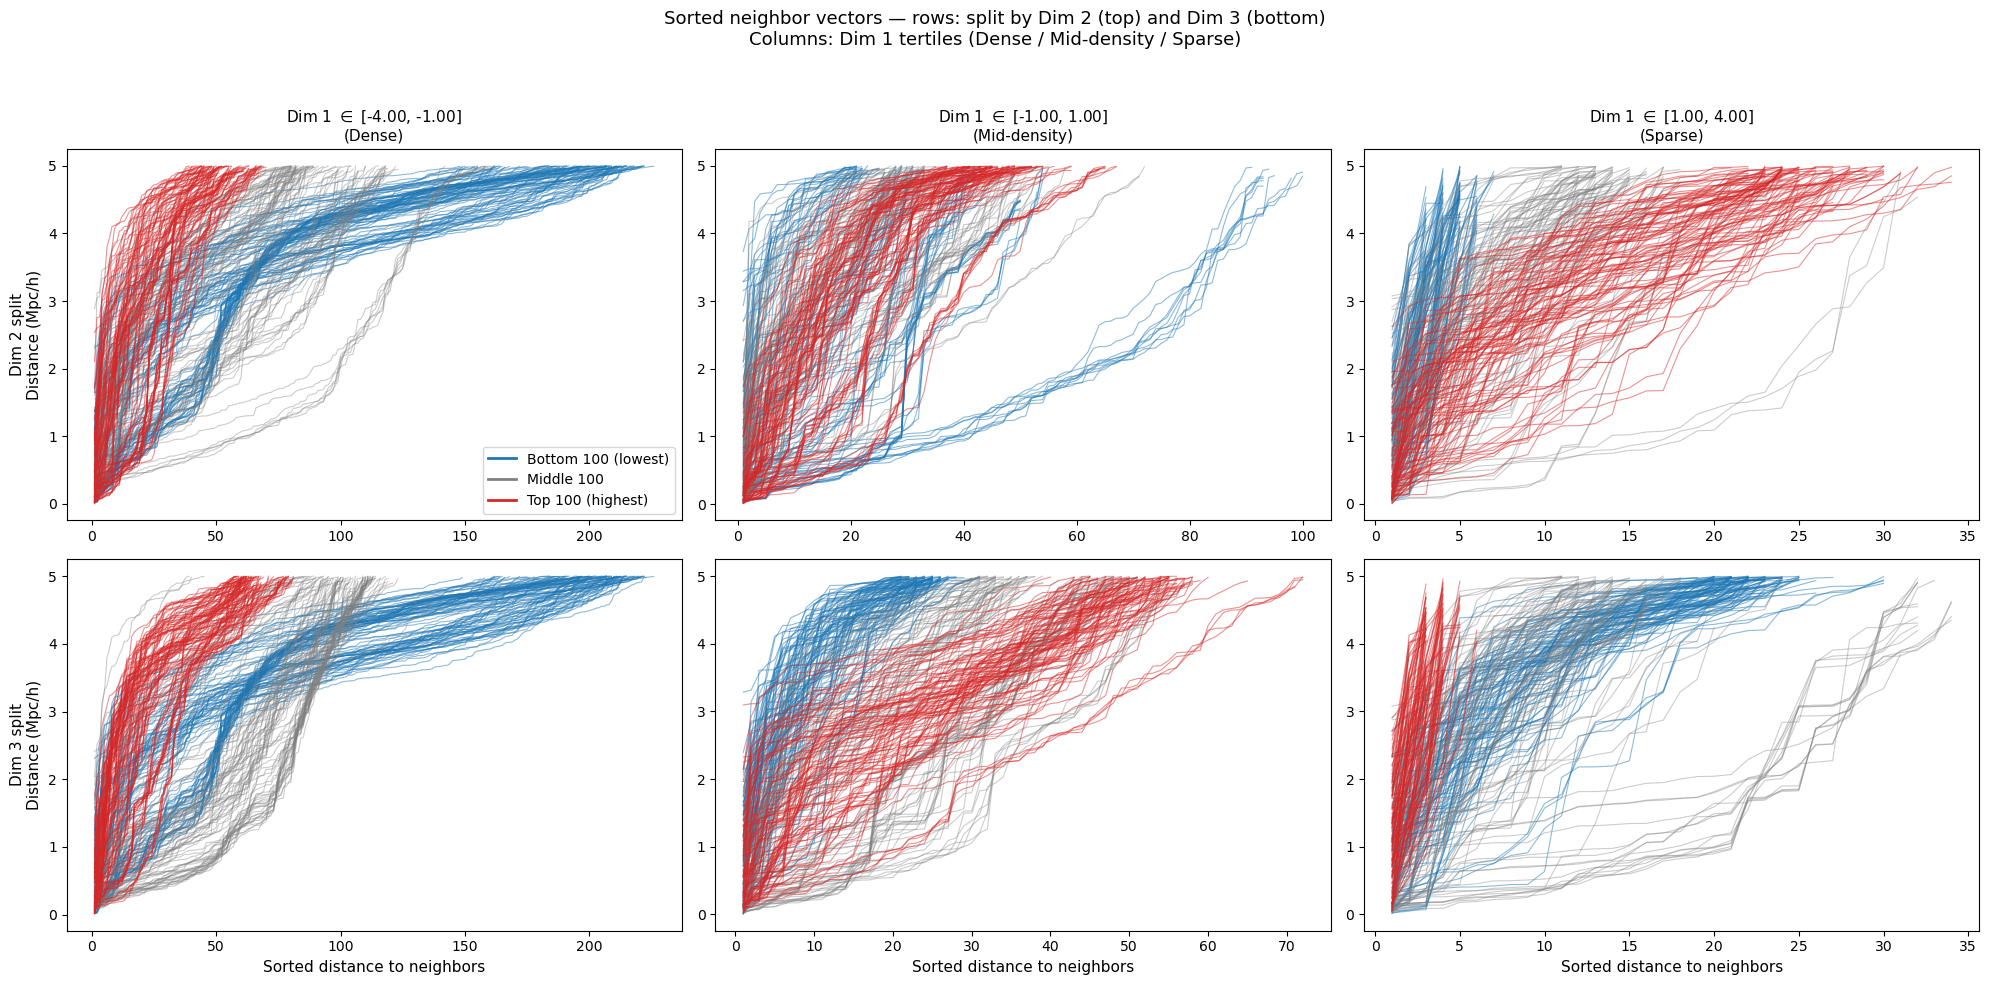

In [16]:
n_per_group = 100
n_strata_d1 = 3

d1_vals = X[99][:, 0]
d1_edges = np.array([-4, -1, 1, 4])  # hand-picked thresholds; switch to np.percentile for tertiles
d1_idx_stratum = np.clip(np.digitize(d1_vals, d1_edges) - 1, 0, n_strata_d1 - 1)
d1_titles = [f'Dim 1 $\\in$ [{d1_edges[i]:.2f}, {d1_edges[i+1]:.2f}]\n'
             f'({"Dense" if i == 0 else "Mid-density" if i == 1 else "Sparse"})'
             for i in range(n_strata_d1)]

fig, axes = plt.subplots(2, n_strata_d1, figsize=(20, 10))

def plot_grouped(ax, dim_to_rank, mask):
    pool = np.where(mask)[0]
    if len(pool) < 3 * n_per_group:
        ax.text(0.5, 0.5, f'Only {len(pool)} galaxies in stratum',
                transform=ax.transAxes, ha='center', va='center')
        return
    sorted_pool = pool[np.argsort(X[99][pool, dim_to_rank])]
    bottom_idx = sorted_pool[:n_per_group]
    top_idx    = sorted_pool[-n_per_group:]
    median_pos = len(sorted_pool) // 2
    mid_idx    = sorted_pool[median_pos - n_per_group // 2 : median_pos + n_per_group // 2]
    for i in bottom_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='tab:blue', alpha=0.5, lw=0.8)
    for i in mid_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='gray', alpha=0.4, lw=0.8)
    for i in top_idx:
        v = sn[99][i]; nz = v[v > 0]
        ax.plot(np.arange(1, len(nz) + 1), nz, color='tab:red', alpha=0.5, lw=0.8)

for col in range(n_strata_d1):
    mask = (d1_idx_stratum == col)
    plot_grouped(axes[0, col], 1, mask)
    axes[0, col].set_title(d1_titles[col], fontsize=11)
    if col == 0:
        axes[0, col].set_ylabel('Dim 2 split\nDistance (Mpc/h)', fontsize=11)
    plot_grouped(axes[1, col], 2, mask)
    if col == 0:
        axes[1, col].set_ylabel('Dim 3 split\nDistance (Mpc/h)', fontsize=11)
    axes[1, col].set_xlabel('Sorted distance to neighbors', fontsize=11)

legend = [
    Line2D([0], [0], color='tab:blue', lw=2, label=f'Bottom {n_per_group} (lowest)'),
    Line2D([0], [0], color='gray',     lw=2, label=f'Middle {n_per_group}'),
    Line2D([0], [0], color='tab:red',  lw=2, label=f'Top {n_per_group} (highest)'),
]
axes[0, 0].legend(handles=legend, fontsize=10, loc='lower right')
fig.suptitle('Sorted neighbor vectors — rows: split by Dim 2 (top) and Dim 3 (bottom)\n'
             'Columns: Dim 1 tertiles (Dense / Mid-density / Sparse)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [27]:
import plotly.express as px
from plotly.offline import plot

fig = px.scatter_3d(
    x=X[99][:, 0],
    y=X[99][:, 1],
    z=X[99][:, 2],
)
fig.update_traces(marker=dict(size=3, color='steelblue', opacity=0.3))
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0),
    scene=dict(
        xaxis_title='Embedding Dim 1 (more ← clustering → less)',
        yaxis_title='Embedding Dim 2',
        zaxis_title='Embedding Dim 3',
    ),
)
plot(fig, filename='galaxies_z0_embedding_3d.html', auto_open=True)
fig.show()


In [29]:
import pandas as pd
import plotly.graph_objects as go
from plotly.offline import plot

props = pd.read_csv('progenitor_properties.csv').set_index('idx_z0').sort_index()
sfr_z0 = props['sfr_snap_99'].to_numpy()

# Quenched threshold (M_sun/yr). TNG has many SFR=0; anything below this is "quenched".
quench_threshold = 1e-3
is_quenched = sfr_z0 < quench_threshold
log_sfr = np.log10(sfr_z0[~is_quenched])

fig = go.Figure()

# Quenched: solid color
fig.add_trace(go.Scatter3d(
    x=X[99][is_quenched, 0], y=X[99][is_quenched, 1], z=X[99][is_quenched, 2],
    mode='markers',
    marker=dict(size=3, color='red', opacity=0.5),
    name=f'Quenched (SFR < {quench_threshold})',
))

# Star-forming: colored by log SFR
fig.add_trace(go.Scatter3d(
    x=X[99][~is_quenched, 0], y=X[99][~is_quenched, 1], z=X[99][~is_quenched, 2],
    mode='markers',
    marker=dict(
        size=3, opacity=0.5,
        color=log_sfr,
        colorscale='Viridis',
        cmin=-2, cmax=1,
        colorbar=dict(title='log10(SFR)'),
    ),
    name='Star-forming',
))

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0),
    scene=dict(
        xaxis_title='Embedding Dim 1 (more ← clustering → less)',
        yaxis_title='Embedding Dim 2',
        zaxis_title='Embedding Dim 3',
    ),
)
plot(fig, filename='galaxies_z0_embedding_3d_sfr.html', auto_open=True)
fig.show()



In [30]:
import pandas as pd
import plotly.express as px
from plotly.offline import plot

H = 0.6774

props = pd.read_csv('progenitor_properties.csv').set_index('idx_z0').sort_index()
# Use m200 (parent FoF M_200crit) as "halo mass". Swap to 'mass_total_snap_99'
# if you'd rather use the bound subhalo mass.
mhalo = props['m200_snap_99'].to_numpy()  # in 1e10 Msun/h
log_mhalo = np.log10(np.clip(mhalo, 1e-5, None) * 1e10 / H)  # in M_sun

fig = px.scatter_3d(
    x=X[99][:, 0],
    y=X[99][:, 1],
    z=X[99][:, 2],
    color=log_mhalo,
    labels={'color': 'log10(M_200 / M_sun)'},
    color_continuous_scale='Viridis',
    range_color=[10.5, 14.5],
)
fig.update_traces(marker=dict(size=3, opacity=0.5))
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0),
    scene=dict(
        xaxis_title='Embedding Dim 1 (more ← clustering → less)',
        yaxis_title='Embedding Dim 2',
        zaxis_title='Embedding Dim 3',
    ),
)
plot(fig, filename='galaxies_z0_embedding_3d_mhalo.html', auto_open=True)
fig.show()


In [31]:

# Load properties (z=0 columns) if not already loaded
props = pd.read_csv('progenitor_properties.csv').set_index('idx_z0').sort_index()

# Tertile bins for each embedding dimension
n_bins = 3
labels = ['L', 'M', 'H']

def tertile_index(vals, n=3):
    edges = np.percentile(vals, np.linspace(0, 100, n + 1))
    return np.clip(np.digitize(vals, edges) - 1, 0, n - 1), edges

d1_idx, d1_edges = tertile_index(X[99][:, 0])
d2_idx, d2_edges = tertile_index(X[99][:, 1])
d3_idx, d3_edges = tertile_index(X[99][:, 2])

print('Tertile edges:')
print(f'  Dim 1: {d1_edges}')
print(f'  Dim 2: {d2_edges}')
print(f'  Dim 3: {d3_edges}')
print()

# Build per-cell summary
rows = []
for b1 in range(n_bins):
    for b2 in range(n_bins):
        for b3 in range(n_bins):
            sel = (d1_idx == b1) & (d2_idx == b2) & (d3_idx == b3)
            n = sel.sum()
            if n == 0:
                rows.append({
                    'Dim1': labels[b1], 'Dim2': labels[b2], 'Dim3': labels[b3],
                    'N': 0, 'log M*': np.nan, 'log M_tot': np.nan,
                    'log M_200': np.nan, 'log SFR': np.nan, 'Star Met': np.nan,
                })
                continue
            idx_in_cell = np.where(sel)[0]
            sub = props.loc[idx_in_cell]

            # Convert TNG code units to physical: masses in 1e10 Msun/h -> Msun
            log_mstar = np.log10(np.clip(sub['mass_stars_snap_99'].to_numpy(), 1e-10, None) * 1e10 / H)
            log_mtot  = np.log10(np.clip(sub['mass_total_snap_99'].to_numpy(),  1e-10, None) * 1e10 / H)
            log_m200  = np.log10(np.clip(sub['m200_snap_99'].to_numpy(),         1e-10, None) * 1e10 / H)
            log_sfr   = np.log10(np.clip(sub['sfr_snap_99'].to_numpy(),          1e-3,  None))
            starmet   = sub['starmet_snap_99'].to_numpy()

            rows.append({
                'Dim1': labels[b1], 'Dim2': labels[b2], 'Dim3': labels[b3],
                'N': int(n),
                'log M*':    float(np.nanmedian(log_mstar)),
                'log M_tot': float(np.nanmedian(log_mtot)),
                'log M_200': float(np.nanmedian(log_m200)),
                'log SFR':   float(np.nanmedian(log_sfr)),
                'Star Met':  float(np.nanmedian(starmet)),
            })

summary = pd.DataFrame(rows)

# Pretty-print by Dim 1 stratum
for b1, lab in enumerate(labels):
    print(f'=== Dim 1 = {lab}  '
          f'(range [{d1_edges[b1]:.2f}, {d1_edges[b1+1]:.2f}]) ===')
    sub = summary[summary['Dim1'] == lab][['Dim2', 'Dim3', 'N',
                                            'log M*', 'log M_tot', 'log M_200',
                                            'log SFR', 'Star Met']]
    print(sub.to_string(index=False,
                        formatters={'log M*': '{:.2f}'.format,
                                    'log M_tot': '{:.2f}'.format,
                                    'log M_200': '{:.2f}'.format,
                                    'log SFR': '{:.2f}'.format,
                                    'Star Met': '{:.4f}'.format}))
    print()


Tertile edges:
  Dim 1: [-3.61919012 -0.83032934  1.55696469  1.94631471]
  Dim 2: [-2.6321032  -0.74091209  0.81734338  1.83501741]
  Dim 3: [-2.00246506 -0.54614745  0.51882639  1.39799482]

=== Dim 1 = L  (range [-3.62, -0.83]) ===
Dim2 Dim3    N log M* log M_tot log M_200 log SFR Star Met
   L    L  793  10.22     11.45     13.75   -1.51   0.0213
   L    M  418  10.20     11.40     14.23   -1.96   0.0219
   L    H    0    NaN       NaN       NaN     NaN      NaN
   M    L    0    NaN       NaN       NaN     NaN      NaN
   M    M  311  10.26     11.34     14.32   -3.00   0.0220
   M    H  690  10.20     11.58     12.64   -0.36   0.0210
   H    L    0    NaN       NaN       NaN     NaN      NaN
   H    M   53  10.10     11.22     14.31   -3.00   0.0222
   H    H 1069  10.22     11.58     12.83   -0.42   0.0209

=== Dim 1 = M  (range [-0.83, 1.56]) ===
Dim2 Dim3    N log M* log M_tot log M_200 log SFR Star Met
   L    L    0    NaN       NaN       NaN     NaN      NaN
   L    M    0 

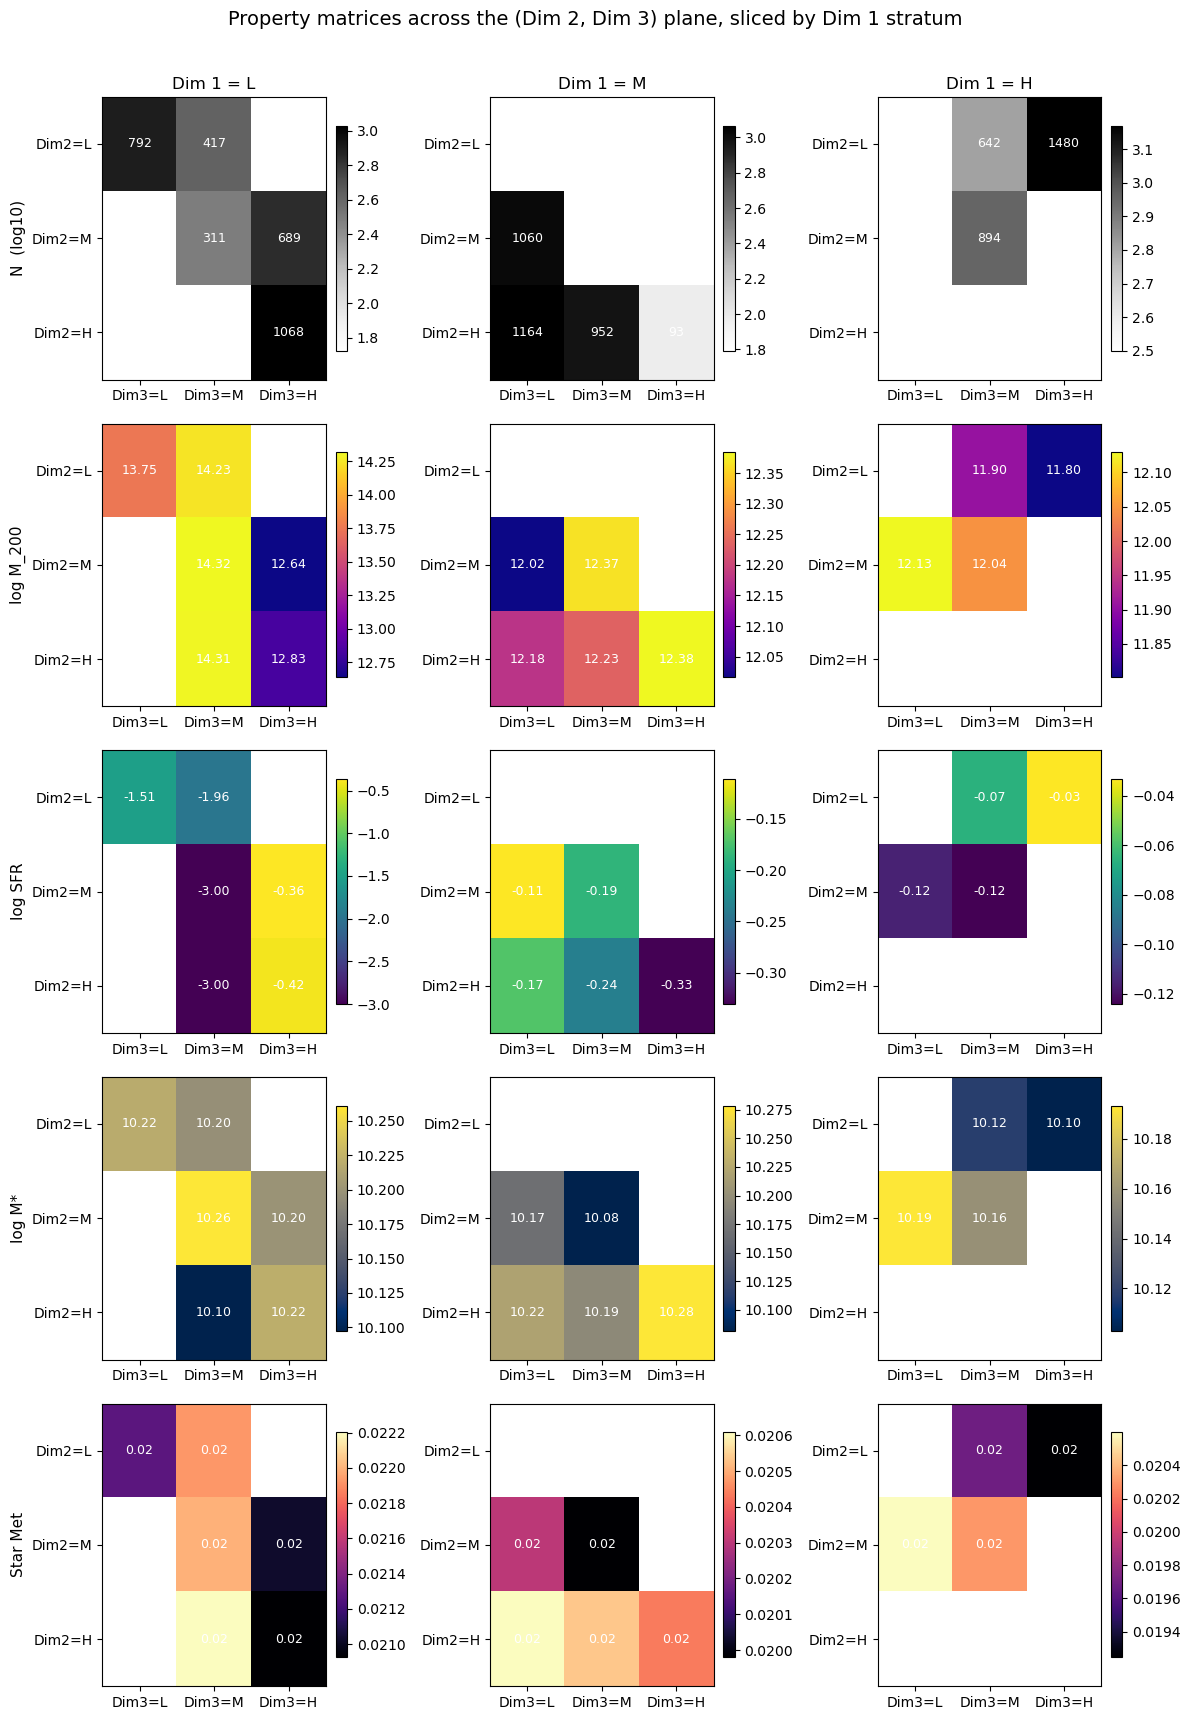

In [33]:
# Build matrices: rows = Dim 2 strata, cols = Dim 3 strata, sliced by Dim 1.
# Each subplot is a 3x3 heatmap.

properties = [
    ('N',         lambda r: r['N'],         'Greys',   'log scale', True),
    ('log M_200', lambda r: r['log M_200'], 'plasma',  '',          False),
    ('log SFR',   lambda r: r['log SFR'],   'viridis', '',          False),
    ('log M*',    lambda r: r['log M*'],    'cividis', '',          False),
    ('Star Met',  lambda r: r['Star Met'],  'magma',   '',          False),
]

n_props = len(properties)
n_d1 = 3
fig, axes = plt.subplots(n_props, n_d1, figsize=(4 * n_d1, 3.5 * n_props))

for col, (b1, lab1) in enumerate(zip(range(n_d1), labels)):
    sub = summary[summary['Dim1'] == lab1]
    for row, (pname, getter, cmap, scale_note, use_log) in enumerate(properties):
        # Build 3x3 matrix: rows = Dim 2 (L/M/H), cols = Dim 3 (L/M/H)
        M = np.full((3, 3), np.nan)
        for _, r in sub.iterrows():
            b2 = labels.index(r['Dim2'])
            b3 = labels.index(r['Dim3'])
            val = getter(r)
            if val == 0 and use_log:
                continue
            M[b2, b3] = np.log10(val) if use_log else val

        ax = axes[row, col]
        im = ax.imshow(M, cmap=cmap, aspect='auto')
        ax.set_xticks(range(3)); ax.set_xticklabels(['Dim3=L', 'Dim3=M', 'Dim3=H'])
        ax.set_yticks(range(3)); ax.set_yticklabels(['Dim2=L', 'Dim2=M', 'Dim2=H'])
        if col == 0:
            ax.set_ylabel(f'{pname}{("  (log10)" if use_log else "")}', fontsize=11)
        if row == 0:
            ax.set_title(f'Dim 1 = {lab1}', fontsize=12)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        # Annotate each cell with its numeric value (or "—" if empty)
        for i in range(3):
            for j in range(3):
                v = M[i, j]
                if np.isnan(v):
                    txt = '—'
                else:
                    txt = f'{int(10**v) if use_log else v:.2f}' if not use_log else f'{int(10**v)}'
                ax.text(j, i, txt, ha='center', va='center',
                        fontsize=9, color='white')

fig.suptitle('Property matrices across the (Dim 2, Dim 3) plane, sliced by Dim 1 stratum',
             fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
